In [1]:
! pip install roboflow ultralytics opencv-python matplotlib "numpy<2,>=1.26.0"

In [2]:
from roboflow import Roboflow
from ultralytics import YOLO
import os
import cv2
import matplotlib.pyplot as plt
import torch

In [3]:
rf = Roboflow(api_key="HJuP30s5hJePCsablmxW")
project = rf.workspace("maryygraceden-q9bha").project("waste-detection-yolo-vykag")
dataset = project.version(1).download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [4]:
data_yaml = dataset.location + "/data.yaml"
print("Dataset YAML path:", data_yaml)

Dataset YAML path: /content/Waste-Detection-YOLO-1/data.yaml


In [5]:
# Load YOLOv8n pretrained model
model = YOLO("yolov8n.pt")

In [6]:
# Device setup
device = 0 if torch.cuda.is_available() else "cpu"
print(" GPU detected" if device == 0 else " No GPU detected - Using CPU")

# Training parameters
batch_size, workers = (16, 8) if device == 0 else (8, 4)

print(f"\n Starting training...")
print(f"   Device: {device}")
print(f"   Batch size: {batch_size}")
print(f"   Epochs: 25")
print(f"   Image size: 320\n")

# Train the model
model.train(
    data=data_yaml,
    epochs=25,
    imgsz=320,
    batch=batch_size,
    device=device,
    name="waste_yolo_fast",
    cache=True,
    workers=workers,
    pretrained=True,
    optimizer="Adam",
    save_period=5,
    patience=50,
    verbose=True
)

print("\n Training completed!")
print(f" Model saved to: runs/detect/waste_yolo_fast/weights/best.pt")

 GPU detected

 Starting training...
   Device: 0
   Batch size: 16
   Epochs: 25
   Image size: 320

Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Waste-Detection-YOLO-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=waste_yolo_fast, nbs=64, nm

In [ ]:
# Step 7: Validation folder path
val_folder = os.path.join(dataset.location, "valid/images")
img_files = [os.path.join(val_folder, f) for f in os.listdir(val_folder) if f.endswith((".jpg", ".png"))]

In [8]:
# Waste classification dictionary
WASTE_INFO = {
    'glass': {'category': 'Recyclable', 'decomposable': False, 'decomposition_time': '1 million years'},
    'metal': {'category': 'Recyclable', 'decomposable': False, 'decomposition_time': '200-500 years'},
    'paper': {'category': 'Recyclable', 'decomposable': True, 'decomposition_time': '2-6 weeks'},
    'plastic': {'category': 'Recyclable', 'decomposable': False, 'decomposition_time': '450+ years'},
    'residual': {'category': 'Non-Recyclable', 'decomposable': False, 'decomposition_time': 'Unknown'}
}

def get_waste_info(class_name):
    return WASTE_INFO.get(class_name.lower(), {'category': 'Unknown', 'decomposable': False, 'decomposition_time': 'Unknown'})

def is_decomposable(detected_classes):
    return any(get_waste_info(c)['decomposable'] for c in detected_classes)

def display_image_with_text(img, detected_classes, decomposable, categories):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 7))

    # Left: text
    plt.subplot(1, 2, 1)
    plt.axis('off')
    plt.text(0, 0.9, "Detected Categories:", fontsize=16, fontweight='bold', color='black')
    plt.text(0, 0.75, ", ".join(detected_classes) if detected_classes else "None", fontsize=14, color='blue')
    plt.text(0, 0.6, f"Category: {', '.join(categories)}", fontsize=14, color='purple')
    plt.text(0, 0.45, f"Decomposable: {'Yes' if decomposable else 'No'}", fontsize=14, color='green' if decomposable else 'red')

    if detected_classes:
        decomposable_items = [c for c in detected_classes if get_waste_info(c)['decomposable']]
        if decomposable_items:
            info = get_waste_info(decomposable_items[0])
            plt.text(0, 0.3, f"Decomposition Time: {info['decomposition_time']}", fontsize=12, color='darkgreen')

    plt.text(0, 0.1, f"Total Detections: {len(detected_classes)}", fontsize=12, color='black')

    # Right: image
    plt.subplot(1, 2, 2)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


Image 1: IMG_20250927_123948_jpg.rf.876bbe4d9739f8558c68dec28884d9ef.jpg

image 1/1 /content/Waste-Detection-YOLO-1/valid/images/IMG_20250927_123948_jpg.rf.876bbe4d9739f8558c68dec28884d9ef.jpg: 640x640 (no detections), 7.3ms
Speed: 1.8ms preprocess, 7.3ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Detected: No waste detected
Categories: None
Decomposable: No


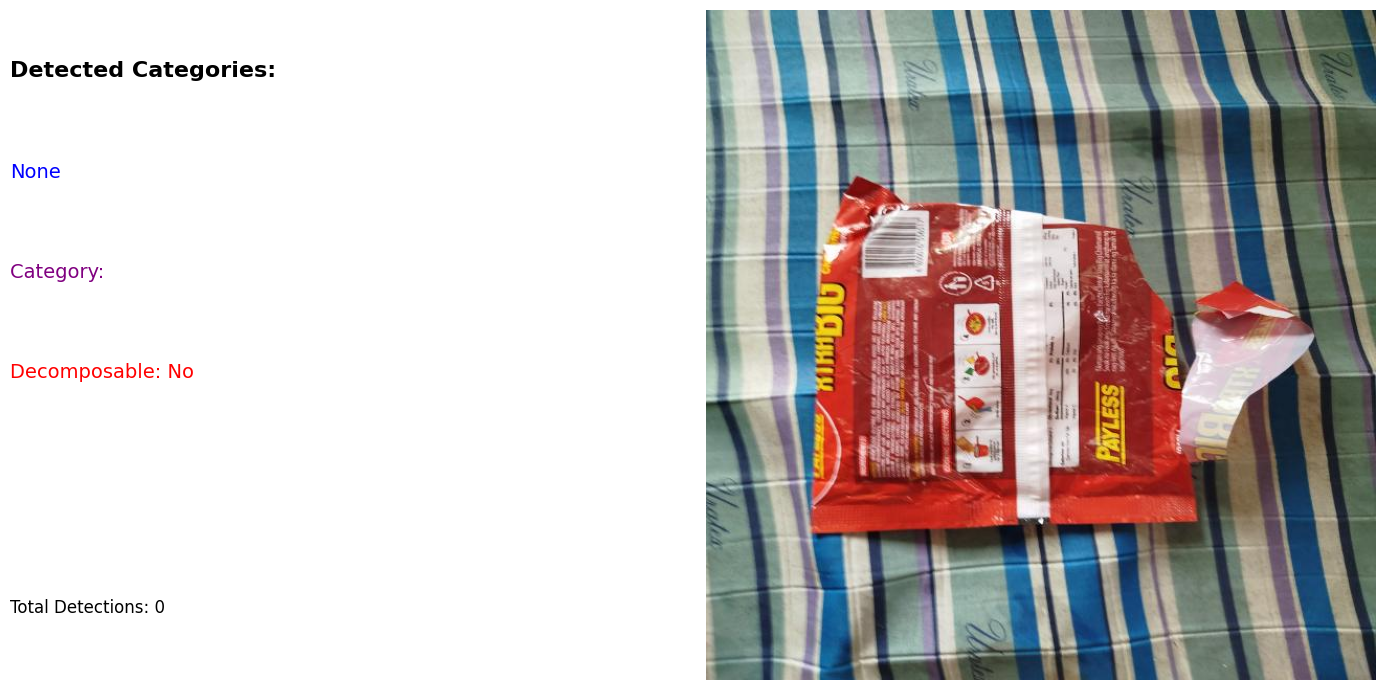


Image 2: IMG_20250927_103225_jpg.rf.7489663d9997248f82ef5fc2977a1681.jpg

image 1/1 /content/Waste-Detection-YOLO-1/valid/images/IMG_20250927_103225_jpg.rf.7489663d9997248f82ef5fc2977a1681.jpg: 640x640 3 papers, 1 plastic, 9.4ms
Speed: 2.7ms preprocess, 9.4ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Detected: plastic, paper, paper, paper
Categories: Recyclable
Decomposable: Yes
  - paper: Recyclable, Decomposable: True
  - plastic: Recyclable, Decomposable: False


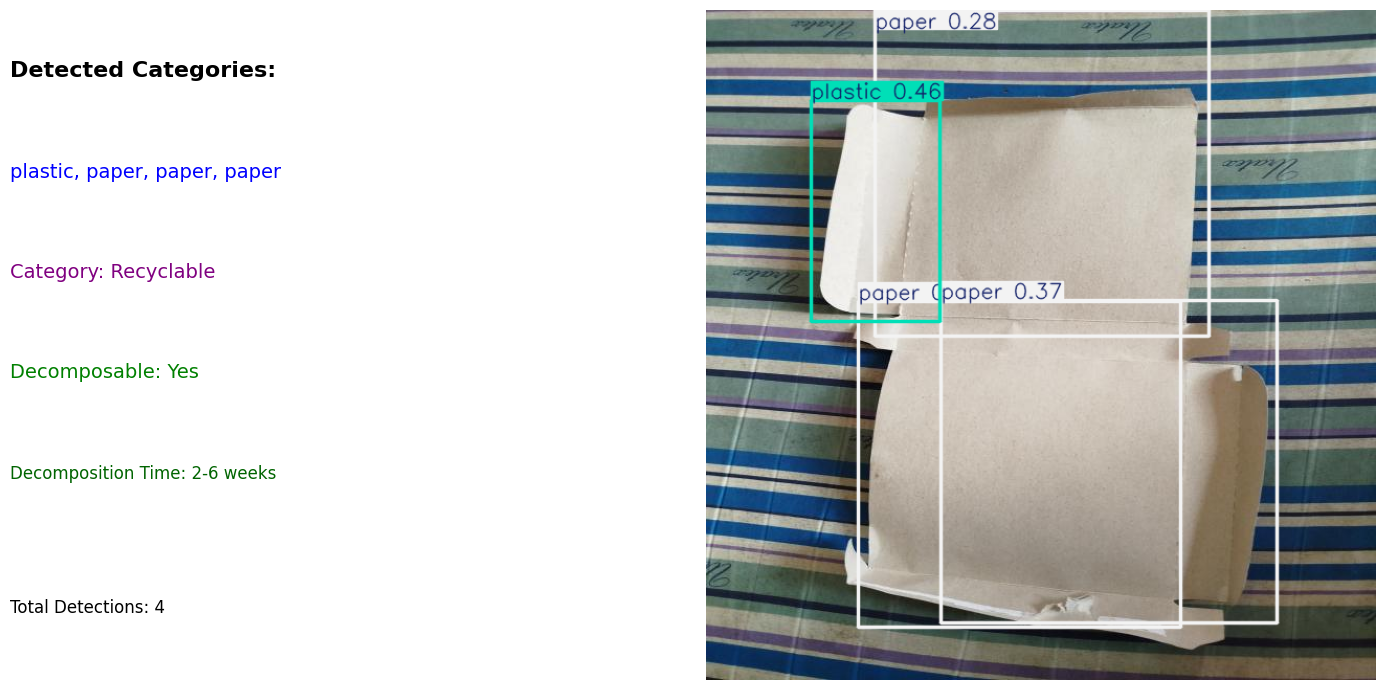


Image 3: images-86-_jpeg.rf.ed874c8dfcddda4fc993309449837885.jpg

image 1/1 /content/Waste-Detection-YOLO-1/valid/images/images-86-_jpeg.rf.ed874c8dfcddda4fc993309449837885.jpg: 640x640 1 paper, 8.9ms
Speed: 3.1ms preprocess, 8.9ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)
Detected: paper
Categories: Recyclable
Decomposable: Yes
  - paper: Recyclable, Decomposable: True


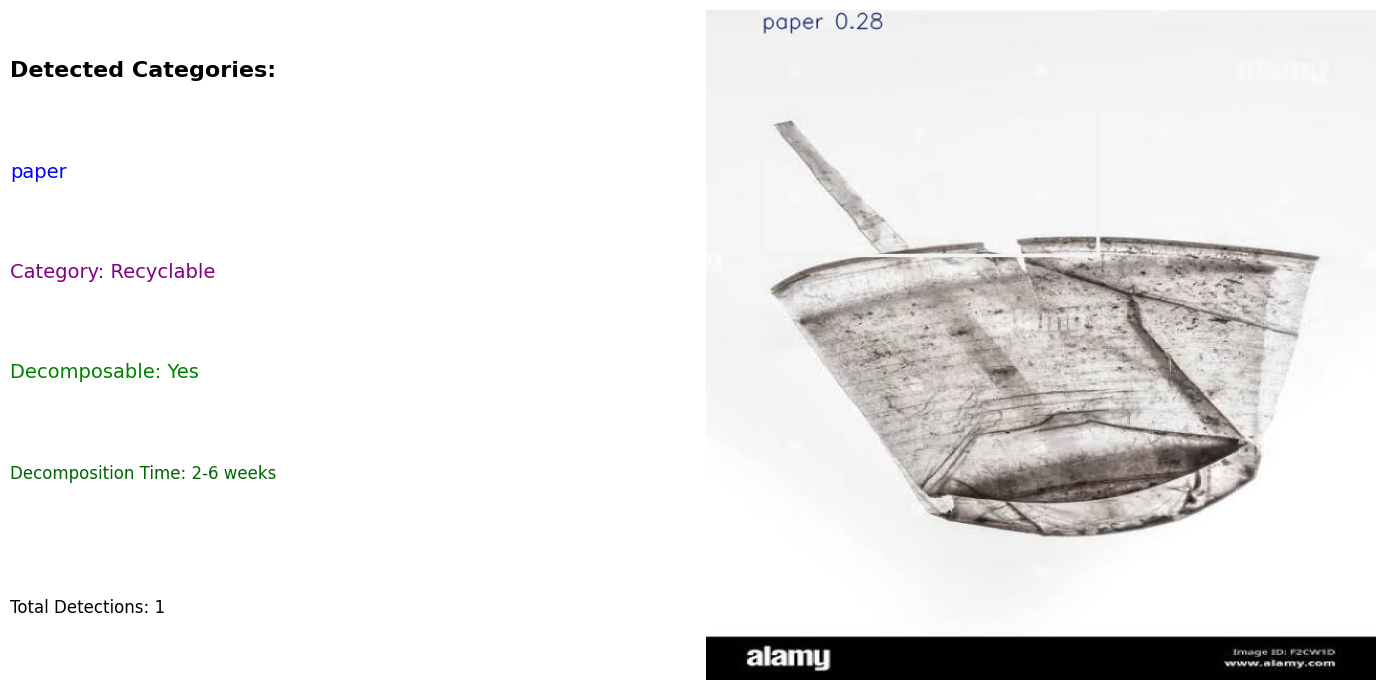


Image 4: IMG_20250906_102142_jpg.rf.5705294f3e181017825648fe69a42e0b.jpg

image 1/1 /content/Waste-Detection-YOLO-1/valid/images/IMG_20250906_102142_jpg.rf.5705294f3e181017825648fe69a42e0b.jpg: 640x640 (no detections), 9.6ms
Speed: 2.8ms preprocess, 9.6ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Detected: No waste detected
Categories: None
Decomposable: No


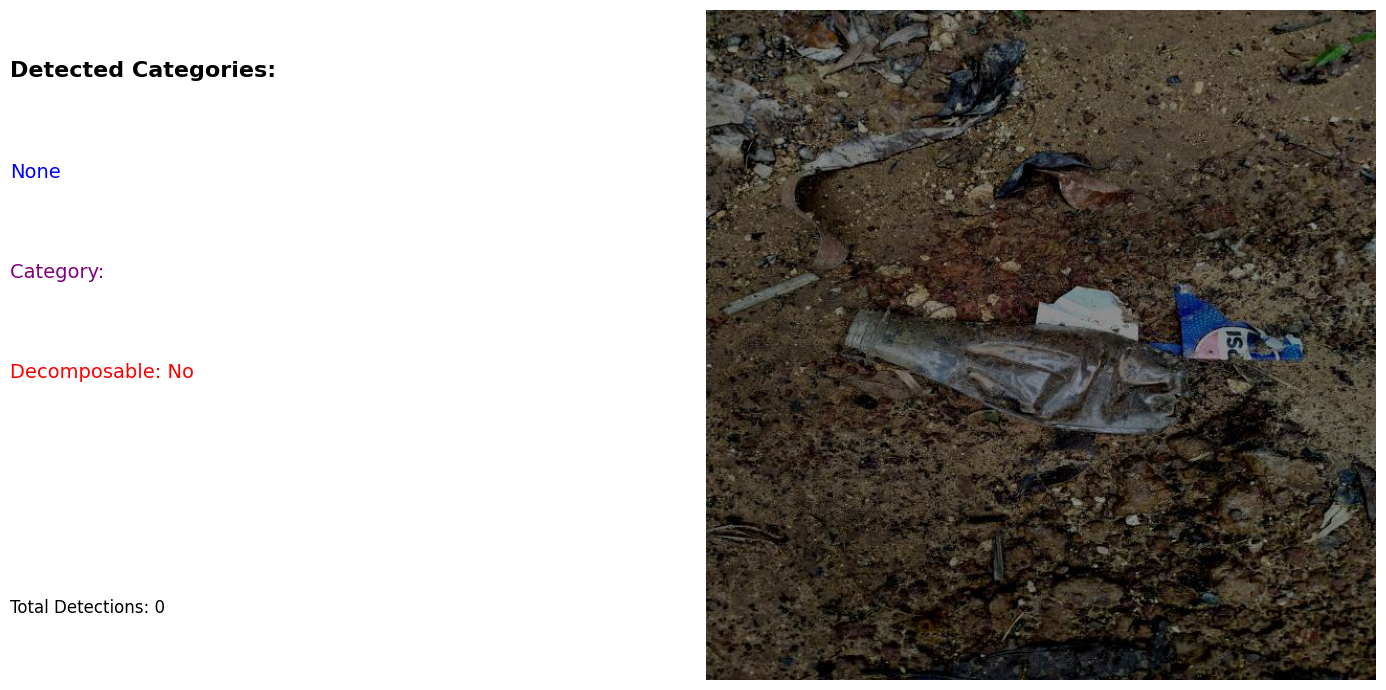


Image 5: IMG_20250927_123850_jpg.rf.ed567a5157408c1404fd0f8e228a1ab6.jpg

image 1/1 /content/Waste-Detection-YOLO-1/valid/images/IMG_20250927_123850_jpg.rf.ed567a5157408c1404fd0f8e228a1ab6.jpg: 640x640 (no detections), 8.1ms
Speed: 2.9ms preprocess, 8.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Detected: No waste detected
Categories: None
Decomposable: No


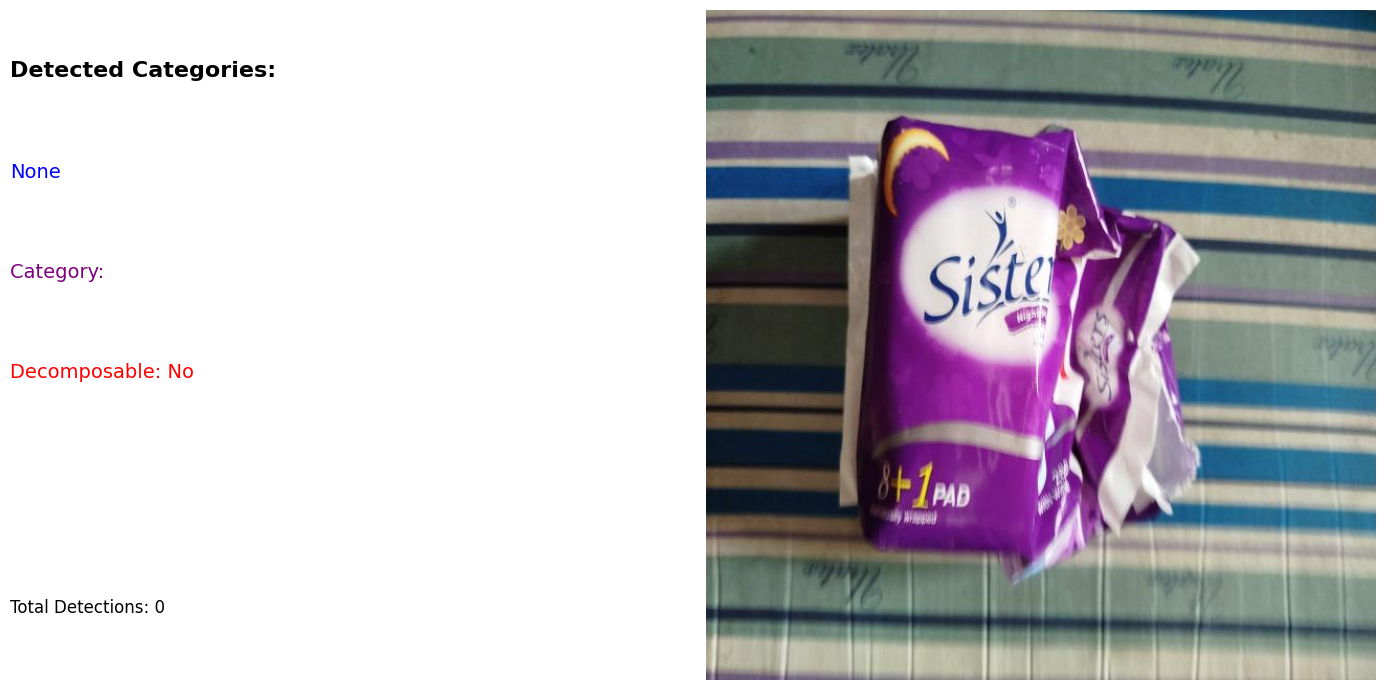

In [9]:
# Run predictions
for idx, img_path in enumerate(img_files[:5]):  # first 5 images
    print(f"\n{'='*60}")
    print(f"Image {idx + 1}: {os.path.basename(img_path)}")
    print('='*60)

    results = model.predict(img_path, imgsz=640, conf=0.25)
    annotated_img = results[0].plot()

    # Extract detected classes
    detected_classes = []
    if results[0].boxes is not None and len(results[0].boxes) > 0:
        detected_classes = [model.names[int(box.cls)] for box in results[0].boxes]

    decomposable = is_decomposable(detected_classes)
    categories = list(set([get_waste_info(c)['category'] for c in detected_classes]))

    print(f"Detected: {', '.join(detected_classes) if detected_classes else 'No waste detected'}")
    print(f"Categories: {', '.join(categories) if categories else 'None'}")
    print(f"Decomposable: {'Yes' if decomposable else 'No'}")

    for class_name in set(detected_classes):
        info = get_waste_info(class_name)
        print(f"  - {class_name}: {info['category']}, Decomposable: {info['decomposable']}")

    display_image_with_text(annotated_img, detected_classes, decomposable, categories)